# Bayesian Spatial Modelling of Seismic Activity — Japan
### Consolidated report

**Team:** Paweł Majerczyk, Jakub Gicala — Data Analytics (AGH, AIR ISZ)

This notebook is a one-page tour of the full analysis. The detailed work lives in
`notebooks/01..06`; here we restate the problem, the two models, and the headline
results, and embed the two key figures. To regenerate everything from scratch see
`README.md`. The analysis notebooks can also be executed programmatically via
`utils.notebook.run_notebook`.

## 1. Problem formulation
We model the **annual count of M ≥ 4.0 earthquakes per 2°×2° grid cell** over
Japan (2000–2023). **Use case:** seismic-hazard assessment / insurance /
infrastructure planning, where a *map with calibrated uncertainty* matters more
than a point estimate. **Data:** USGS Earthquake Catalog API (CSV, no key),
downloaded year-by-year (20k-record limit) — ~33 000 events. **Preprocessing:**
point epicentres are binned to the grid and aggregated to one Poisson count per
cell-year (154 active cells, 2086 cell-year observations).

## 2. The two models (structural difference)
$$\text{count}_{c,y}\sim\text{Poisson}(\lambda_c),\qquad \log\lambda_c=\alpha_c.$$

| | **Model 1 — no pooling** | **Model 2 — partial pooling** |
|---|---|---|
| per-cell prior | $\alpha_c\sim\mathcal N(2,\,2)$ | $\alpha_c\sim\mathcal N(\mu_g,\sigma_g)$ |
| scale $\sigma$ | **fixed** | **estimated** ($\sigma_g\sim$ HalfNormal(1)) |
| cells | independent | borrow strength (shrinkage) |

The difference is **structural** (an estimated hierarchical scale), not just an
added covariate. Both use a Poisson **log link** (`poisson_log`, never `abs`) and
emit `log_lik` for model comparison.

## 3. Priors
The prior $\alpha\sim\mathcal N(2,2)$ was derived from physical bounds: a typical
active cell ~exp(2)≈7 events/yr, with ±3σ spanning log-rates 0→8 (1→~3000
events/yr, covering the 2011 extreme in the tail). **Both** prior predictive
checks pass — implied rates and simulated counts are positive, right-skewed, and
within the geophysical bound while still covering the observed range (notebook 03).

## 4–5. Posteriors
Both models converge cleanly (no divergences, $\hat R<1.01$; Model 2 uses a
non-centered parameterization + `adapt_delta=0.95`). Model 1 leaves **data-poor
cells with wide, prior-driven posteriors**; Model 2's **shrinkage** pulls them
toward the global mean and narrows their intervals, while data-rich cells are
unchanged. The estimated `sigma_global` ≈ 1.3 confirms the data support a shared
baseline. For **both** models the 2011 Tohoku cell-years are documented outliers
— a *stationary* Poisson rate cannot represent a one-off regime change.

Raw earthquake epicentres (input):


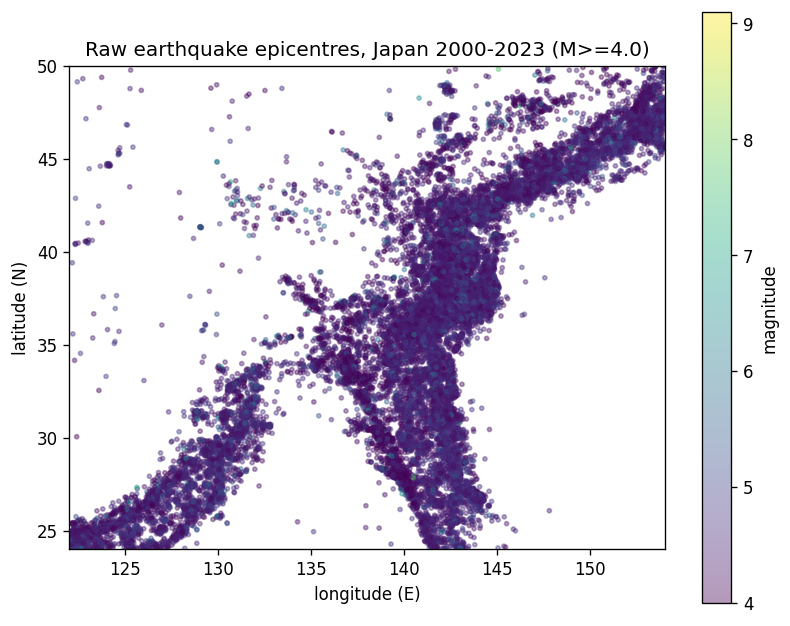

Model 2 posterior-mean intensity (headline deliverable):


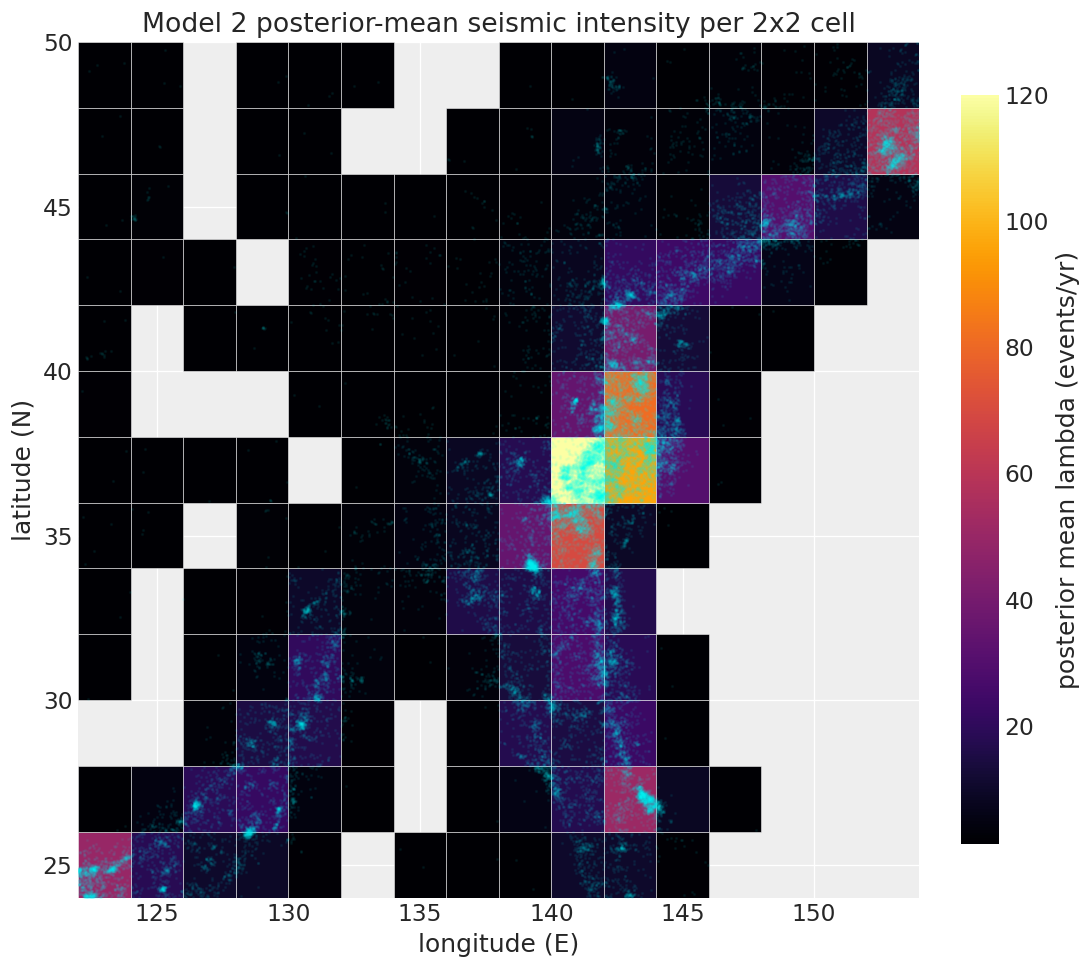

In [1]:
import sys; sys.path.append("..")
from utils.display import display_image
print("Raw earthquake epicentres (input):")
display_image("figures/01_raw_map.png", width=480)
print("Model 2 posterior-mean intensity (headline deliverable):")
display_image("figures/05_posterior_map.png", width=480)

## 6. Model comparison & final assessment
- **WAIC:** Model 2 wins by ~61 elpd (~1.6 SE) — *with warning*.
- **PSIS-LOO:** ranking **flips**, Model 1 wins by ~26 elpd (~1.6 SE) — *with
  warning*; Pareto-$k$ up to ~9, concentrated on the highest-count / 2011 cells.

The criteria **disagree and both warn**, because a few extreme, misspecified
observations (2011 Tohoku) dominate them — so they cannot crown a winner on their
own. We nonetheless **prefer Model 2**: it regularises data-poor cells, its
hierarchy is data-supported, it costs one parameter, and it yields the
honest, smooth intensity map the use case needs. The real next step is a
**non-stationary** intensity to absorb 2011, after which the criteria would
become reliable (Pareto-$k<0.7$) and arbitrate cleanly.